# Purchase Propensity Model Training

This executed notebook implements the canonical research-paper model. It reads an external session-level CSV, enforces the seven-variable session-start contract, trains hashed logistic regression and categorical Naive Bayes, and displays all reviewed holdout outputs.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
print("Training notebook environment loaded.")

Training notebook environment loaded.


## Deterministic pipeline implementation

In [2]:
"""Leakage-safe chronological purchase-propensity training pipeline.

This implementation intentionally uses only NumPy and pandas so the project can
run in the bundled workspace without downloading packages.  The deployable
feature contract is limited to attributes known at session start.
"""
from __future__ import annotations

import argparse
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

LABEL = "converted"
DATE = "session_date"
KEY = "session_id"
TEST_START = pd.Timestamp("2021-01-11")

SAFE_FEATURES = [
    "day_of_week",
    "is_weekend",
    "traffic_source",
    "traffic_medium",
    "device_category",
    "operating_system",
    "country",
]

PROHIBITED = {
    "user_pseudo_id",
    "ga_session_id",
    "total_events",
    "distinct_event_types",
    "page_views",
    "product_views",
    "add_to_cart_events",
    "checkout_events",
    "shipping_events",
    "payment_events",
    "purchase_events",
    "viewed_product",
    "added_to_cart",
    "began_checkout",
    "added_shipping_info",
    "added_payment_info",
    "transaction_count",
    "revenue",
    "session_duration_seconds",
    "engagement_time_seconds",
}


def leakage_audit(df: pd.DataFrame) -> dict:
    missing = sorted(set(SAFE_FEATURES + [KEY, DATE, LABEL]) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    used_prohibited = sorted(set(SAFE_FEATURES) & PROHIBITED)
    if used_prohibited:
        raise ValueError(f"Target-leakage columns detected: {used_prohibited}")
    return {
        "safe_features": SAFE_FEATURES,
        "prohibited_columns_present_but_excluded": sorted(PROHIBITED & set(df.columns)),
        "status": "passed",
    }


def stable_bucket(value: str, column: str, buckets: int) -> int:
    raw = f"{column}={value}".encode("utf-8", errors="replace")
    return int.from_bytes(hashlib.blake2b(raw, digest_size=8).digest(), "little") % buckets


def hash_matrix(df: pd.DataFrame, buckets: int) -> np.ndarray:
    matrices = []
    for column in SAFE_FEATURES:
        values = df[column].fillna("<MISSING>").astype(str)
        uniques = values.unique()
        mapping = {v: stable_bucket(v, column, buckets) for v in uniques}
        matrices.append(values.map(mapping).to_numpy(dtype=np.int32))
    return np.column_stack(matrices)


def sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-z))


def fit_hashed_logistic(
    x_idx: np.ndarray,
    y: np.ndarray,
    buckets: int,
    epochs: int = 30,
    batch_size: int = 8192,
    learning_rate: float = 0.08,
    l2: float = 1e-5,
) -> tuple[np.ndarray, float, list[float]]:
    """Fit sparse hashed logistic regression with Adam mini-batch updates."""
    rng = np.random.default_rng(20260729)
    w = np.zeros(buckets, dtype=np.float64)
    b = float(np.log(y.mean() / (1.0 - y.mean())))
    mw = np.zeros_like(w)
    vw = np.zeros_like(w)
    mb = vb = 0.0
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    step = 0
    history = []

    for _ in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            ids = order[start : start + batch_size]
            xb, yb = x_idx[ids], y[ids]
            p = sigmoid(b + w[xb].sum(axis=1))
            err = p - yb
            grad = np.zeros_like(w)
            for j in range(xb.shape[1]):
                np.add.at(grad, xb[:, j], err)
            grad = grad / len(ids) + l2 * w
            grad_b = float(err.mean())

            step += 1
            mw = beta1 * mw + (1 - beta1) * grad
            vw = beta2 * vw + (1 - beta2) * (grad * grad)
            mb = beta1 * mb + (1 - beta1) * grad_b
            vb = beta2 * vb + (1 - beta2) * (grad_b * grad_b)
            w -= learning_rate * (mw / (1 - beta1**step)) / (
                np.sqrt(vw / (1 - beta2**step)) + eps
            )
            b -= learning_rate * (mb / (1 - beta1**step)) / (
                np.sqrt(vb / (1 - beta2**step)) + eps
            )
        p_all = sigmoid(b + w[x_idx].sum(axis=1))
        loss = float(
            -np.mean(y * np.log(np.clip(p_all, 1e-12, 1)) +
                     (1 - y) * np.log(np.clip(1 - p_all, 1e-12, 1)))
        )
        history.append(loss)
    return w, b, history


def fit_categorical_naive_bayes(
    train: pd.DataFrame, y: np.ndarray, alpha: float = 10.0
) -> dict:
    model = {"prior": float((y.sum() + alpha) / (len(y) + 2 * alpha)), "columns": {}}
    for column in SAFE_FEATURES:
        values = train[column].fillna("<MISSING>").astype(str)
        table = pd.crosstab(values, y)
        for cls in [0, 1]:
            if cls not in table.columns:
                table[cls] = 0
        n_values = len(table) + 1
        probs = {}
        defaults = {}
        for cls in [0, 1]:
            denom = float((y == cls).sum() + alpha * n_values)
            probs[str(cls)] = ((table[cls] + alpha) / denom).to_dict()
            defaults[str(cls)] = alpha / denom
        model["columns"][column] = {"probs": probs, "defaults": defaults}
    return model


def predict_categorical_naive_bayes(model: dict, frame: pd.DataFrame) -> np.ndarray:
    prior = model["prior"]
    log0 = np.full(len(frame), np.log(1 - prior), dtype=float)
    log1 = np.full(len(frame), np.log(prior), dtype=float)
    for column in SAFE_FEATURES:
        values = frame[column].fillna("<MISSING>").astype(str)
        spec = model["columns"][column]
        p0 = values.map(spec["probs"]["0"]).fillna(spec["defaults"]["0"]).to_numpy()
        p1 = values.map(spec["probs"]["1"]).fillna(spec["defaults"]["1"]).to_numpy()
        log0 += np.log(p0)
        log1 += np.log(p1)
    return sigmoid(log1 - log0)


def average_precision(y: np.ndarray, p: np.ndarray) -> float:
    order = np.argsort(-p, kind="mergesort")
    ys = y[order]
    positives = ys.sum()
    if positives == 0:
        return float("nan")
    precision = np.cumsum(ys) / np.arange(1, len(ys) + 1)
    return float((precision * ys).sum() / positives)


def roc_auc(y: np.ndarray, p: np.ndarray) -> float:
    order = np.argsort(p, kind="mergesort")
    ranks = np.empty(len(p), dtype=float)
    sorted_p = p[order]
    i = 0
    while i < len(p):
        j = i + 1
        while j < len(p) and sorted_p[j] == sorted_p[i]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2.0
        i = j
    n1 = y.sum()
    n0 = len(y) - n1
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def model_metrics(y: np.ndarray, p: np.ndarray, capacity: float = 0.10) -> dict:
    clipped = np.clip(p, 1e-12, 1 - 1e-12)
    n_top = max(1, int(np.ceil(len(y) * capacity)))
    top = np.argsort(-p)[:n_top]
    base = float(y.mean())
    top_rate = float(y[top].mean())
    return {
        "pr_auc": average_precision(y, p),
        "roc_auc": roc_auc(y, p),
        "log_loss": float(-np.mean(y * np.log(clipped) + (1 - y) * np.log(1 - clipped))),
        "brier_score": float(np.mean((p - y) ** 2)),
        "recall_at_top_10pct": float(y[top].sum() / y.sum()),
        "conversion_rate_top_10pct": top_rate,
        "lift_top_10pct": float(top_rate / base),
    }


def decile_table(y: np.ndarray, p: np.ndarray) -> pd.DataFrame:
    order = np.argsort(-p, kind="mergesort")
    decile = np.empty(len(y), dtype=int)
    decile[order] = np.minimum(10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1)
    d = pd.DataFrame({"converted": y, "score": p, "score_decile": decile})
    base = d["converted"].mean()
    out = d.groupby("score_decile").agg(
        sessions=("converted", "size"),
        purchases=("converted", "sum"),
        avg_score=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()
    out["lift_vs_average"] = out["observed_rate"] / base
    return out


def calibration_table(y: np.ndarray, p: np.ndarray) -> pd.DataFrame:
    order = np.argsort(p, kind="mergesort")
    band = np.empty(len(y), dtype=int)
    band[order] = np.minimum(10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1)
    d = pd.DataFrame({"converted": y, "score": p, "risk_band": band})
    return d.groupby("risk_band").agg(
        sessions=("converted", "size"),
        predicted_rate=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()


def serializable_nb(model: dict) -> dict:
    clean = {"prior": model["prior"], "columns": {}}
    for column, spec in model["columns"].items():
        clean["columns"][column] = {
            "defaults": spec["defaults"],
            "probs": {
                cls: {str(k): float(v) for k, v in values.items()}
                for cls, values in spec["probs"].items()
            },
        }
    return clean


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--hash-buckets", type=int, default=2048)
    args = parser.parse_args()

    out = Path(args.output)
    out.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(args.input, parse_dates=[DATE])
    audit = leakage_audit(df)
    train = df[df[DATE] < TEST_START].copy()
    test = df[df[DATE] >= TEST_START].copy()
    if train.empty or test.empty:
        raise ValueError("Chronological split produced an empty train or test set")
    y_train = train[LABEL].astype(int).to_numpy()
    y_test = test[LABEL].astype(int).to_numpy()

    x_train = hash_matrix(train, args.hash_buckets)
    x_test = hash_matrix(test, args.hash_buckets)
    weights, intercept, history = fit_hashed_logistic(
        x_train, y_train, args.hash_buckets
    )
    p_logistic = sigmoid(intercept + weights[x_test].sum(axis=1))

    nb_model = fit_categorical_naive_bayes(train, y_train)
    p_nb = predict_categorical_naive_bayes(nb_model, test)

    probabilities = {
        "hashed_logistic_regression": p_logistic,
        "categorical_naive_bayes": p_nb,
    }
    results = {name: model_metrics(y_test, p) for name, p in probabilities.items()}
    winner = max(results, key=lambda name: results[name]["pr_auc"])

    for name, p in probabilities.items():
        pd.DataFrame({
            KEY: test[KEY].astype(str).to_numpy(),
            DATE: test[DATE].dt.strftime("%Y-%m-%d").to_numpy(),
            LABEL: y_test,
            "predicted_probability": p,
        }).to_csv(out / f"{name}_scores.csv", index=False)
        decile_table(y_test, p).to_csv(out / f"{name}_lift_by_decile.csv", index=False)
        calibration_table(y_test, p).to_csv(out / f"{name}_calibration.csv", index=False)

    np.savez_compressed(
        out / "hashed_logistic_model.npz",
        weights=weights,
        intercept=np.array([intercept]),
        hash_buckets=np.array([args.hash_buckets]),
    )
    (out / "categorical_naive_bayes_model.json").write_text(
        json.dumps(serializable_nb(nb_model), indent=2), encoding="utf-8"
    )
    payload = {
        "data": {
            "rows": int(len(df)),
            "train_rows": int(len(train)),
            "test_rows": int(len(test)),
            "train_purchases": int(y_train.sum()),
            "test_purchases": int(y_test.sum()),
            "train_conversion_rate": float(y_train.mean()),
            "test_conversion_rate": float(y_test.mean()),
        },
        "split": {
            "train_start": str(train[DATE].min().date()),
            "train_end": str(train[DATE].max().date()),
            "test_start": str(test[DATE].min().date()),
            "test_end": str(test[DATE].max().date()),
        },
        "feature_contract": audit,
        "models": results,
        "selected_by_pr_auc": winner,
        "training_loss": history,
    }
    (out / "model_metrics.json").write_text(
        json.dumps(payload, indent=2), encoding="utf-8"
    )
    print(json.dumps(payload, indent=2))



print("Training pipeline functions defined.")


Training pipeline functions defined.


## Execute leakage audit and chronological model training

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
data_candidates = [
    PROJECT_ROOT / "data" / "session_level_ecommerce.csv.gz",
    PROJECT_ROOT / "data" / "session_level_ecommerce.csv",
    PROJECT_ROOT / "session_level_ecommerce.csv.gz",
    PROJECT_ROOT / "session_level_ecommerce.csv",
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("External session-level CSV not found.")

df = pd.read_csv(DATA_PATH, parse_dates=[DATE])
audit = leakage_audit(df)
audit_table = pd.DataFrame({
    "control": [
        "Eligible features", "Prediction timing", "Target",
        "Post-session features used", "Status",
    ],
    "result": [
        len(audit["safe_features"]), "Session start", "Any purchase in session",
        "None", audit["status"].title(),
    ],
})
display(audit_table)

train = df[df[DATE] < TEST_START].copy()
test = df[df[DATE] >= TEST_START].copy()
y_train = train[LABEL].astype(int).to_numpy()
y_test = test[LABEL].astype(int).to_numpy()

HASH_BUCKETS = 2_048
x_train = hash_matrix(train, HASH_BUCKETS)
x_test = hash_matrix(test, HASH_BUCKETS)
weights, intercept, training_loss = fit_hashed_logistic(
    x_train, y_train, HASH_BUCKETS
)
p_logistic = sigmoid(intercept + weights[x_test].sum(axis=1))

nb_model = fit_categorical_naive_bayes(train, y_train)
p_nb = predict_categorical_naive_bayes(nb_model, test)
probabilities = {
    "Hashed logistic regression": p_logistic,
    "Categorical Naive Bayes": p_nb,
}
results = pd.DataFrame({
    name: model_metrics(y_test, probability)
    for name, probability in probabilities.items()
}).T
results = results.rename(columns={
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "log_loss": "Log loss",
    "brier_score": "Brier score",
    "recall_at_top_10pct": "Top-10% recall",
    "lift_top_10pct": "Top-10% lift",
})
display(results[[
    "PR-AUC", "ROC-AUC", "Log loss", "Brier score",
    "Top-10% recall", "Top-10% lift",
]].round(5))
print(
    f"Train: {len(train):,} sessions | Test: {len(test):,} sessions\n"
    f"Selected by PR-AUC: {results['PR-AUC'].idxmax()}"
)

control,result
Eligible features,7
Prediction timing,Session start
Target,Any purchase in session
Post-session features used,None
Status,Passed


model,PR-AUC,ROC-AUC,Log loss,Brier score,Top-10% recall,Top-10% lift
Hashed logistic regression,0.01708,0.58678,0.06089,0.01105,0.20066,2.00651
Categorical Naive Bayes,0.01682,0.59474,0.06306,0.01138,0.20285,2.02843


Train: 228,487 sessions | Test: 81,527 sessions
Selected by PR-AUC: Hashed logistic regression


## Model validation figure

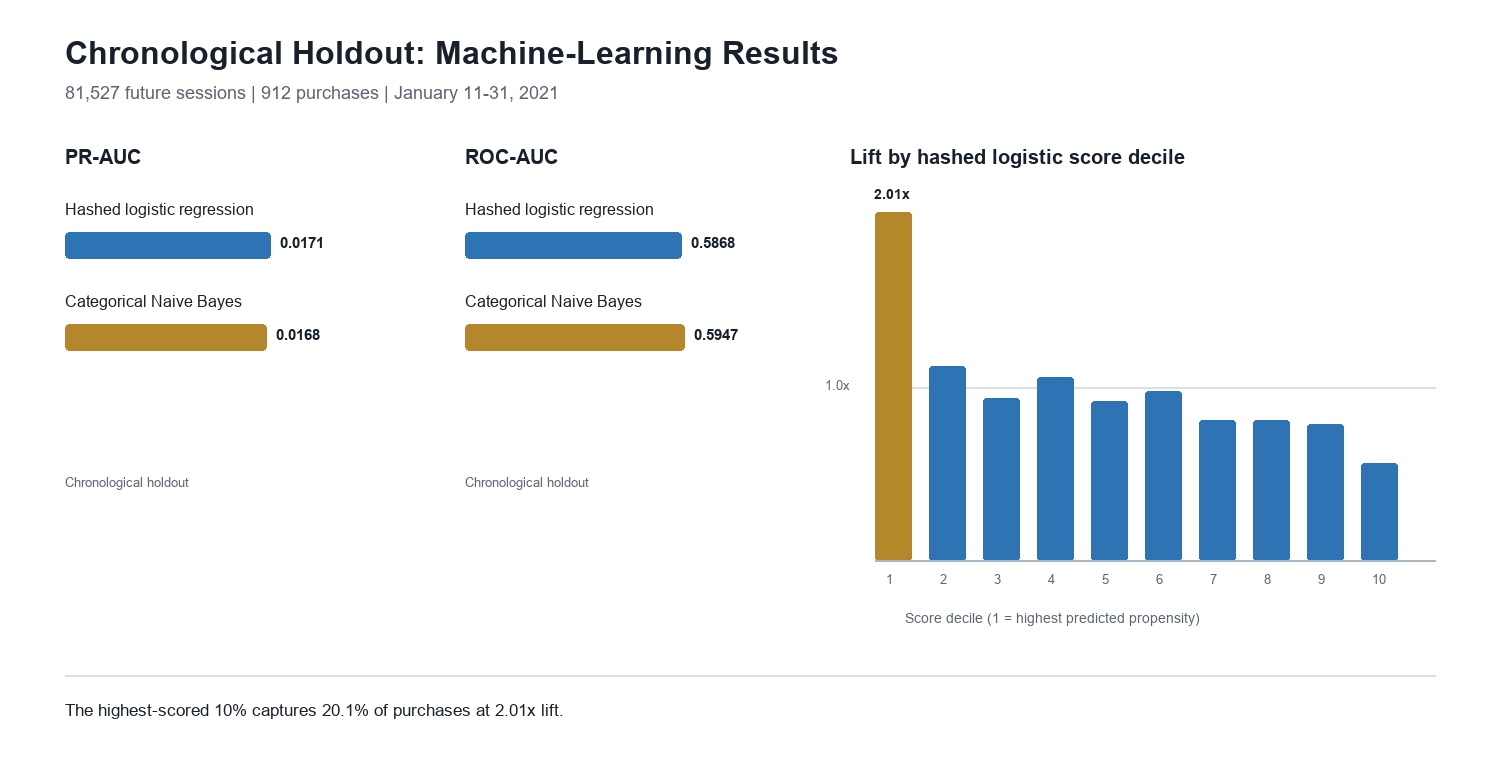

In [4]:
from IPython.display import Image, display
display(Image(filename=str(PROJECT_ROOT / "assets" / "model-validation.png")))

The highest-scored 10% contains approximately twice the average purchase density. Scores should support experiment prioritization and randomized allocation, not autonomous treatment or causal claims.